# <b>Retail Customer Prediction</b>

**Problem Statement:**

Sebuah perusahaan ritel besar ingin meningkatkan strategi pemasaran mereka dengan memahami pola pembelian pelanggan mereka secara lebih mendalam. Berdasarkan data transaksi mereka, perusahaan ingin memprediksi jenis produk yang cenderung dibeli oleh pelanggan berdasarkan karakteristik demografis dan detail transaksi mereka.


**Tujuan:**
Membantu sales atau tim marketing dalam mencari peluang strategi pemasaran dengan hasil olahan data yang diprediksi dan bisa mengambil keputusan peluang untuk mengarahkan ke customer agar mendapatkan hasil profit bagi perusahaan maupun kalangan industri ritel.

## Import Library

In [ ]:
!pip -q install skl2onnx onnx onnxruntime

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import onnx
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import missingno as msno
import plotly.express as px
from scipy.stats import zscore
import matplotlib.pyplot as plt
from skl2onnx import convert_sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from skl2onnx.common.data_types import FloatTensorType
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

## Load Dataset

In [ ]:
data_ritel = pd.read_csv('/content/drive/MyDrive/Proyek/Data Science/Retail System/dataset/customer_shopping_data.csv')
data_ritel.sample(25)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
76954,I810415,C278754,Female,47,Cosmetics,2,81.32,Cash,18/01/2023,Kanyon
35363,I277240,C292985,Male,32,Clothing,5,1500.40,Cash,22/04/2022,Metropol AVM
37004,I159413,C218675,Male,58,Shoes,5,3000.85,Cash,8/6/2022,Zorlu Center
34032,I967768,C789749,Female,29,Cosmetics,5,203.30,Cash,23/06/2021,Kanyon
84970,I176140,C194540,Male,63,Food & Beverage,4,20.92,Cash,6/4/2021,Emaar Square Mall
94389,I241630,C519854,Female,21,Cosmetics,4,162.64,Debit Card,12/1/2021,Zorlu Center
93762,I866224,C328206,Female,44,Clothing,2,600.16,Debit Card,21/02/2022,Metrocity
87617,I189148,C134475,Female,38,Clothing,3,900.24,Credit Card,8/3/2021,Kanyon
61424,I249903,C116157,Female,47,Clothing,1,300.08,Cash,18/07/2021,Metropol AVM
58749,I997342,C186051,Male,31,Food & Beverage,5,26.15,Cash,7/2/2023,Istinye Park


In [ ]:
data_ritel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [ ]:
data_ritel.shape

(99457, 10)

## Exploratory Data Analysis

In [ ]:
data_ritel.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


<Axes: >

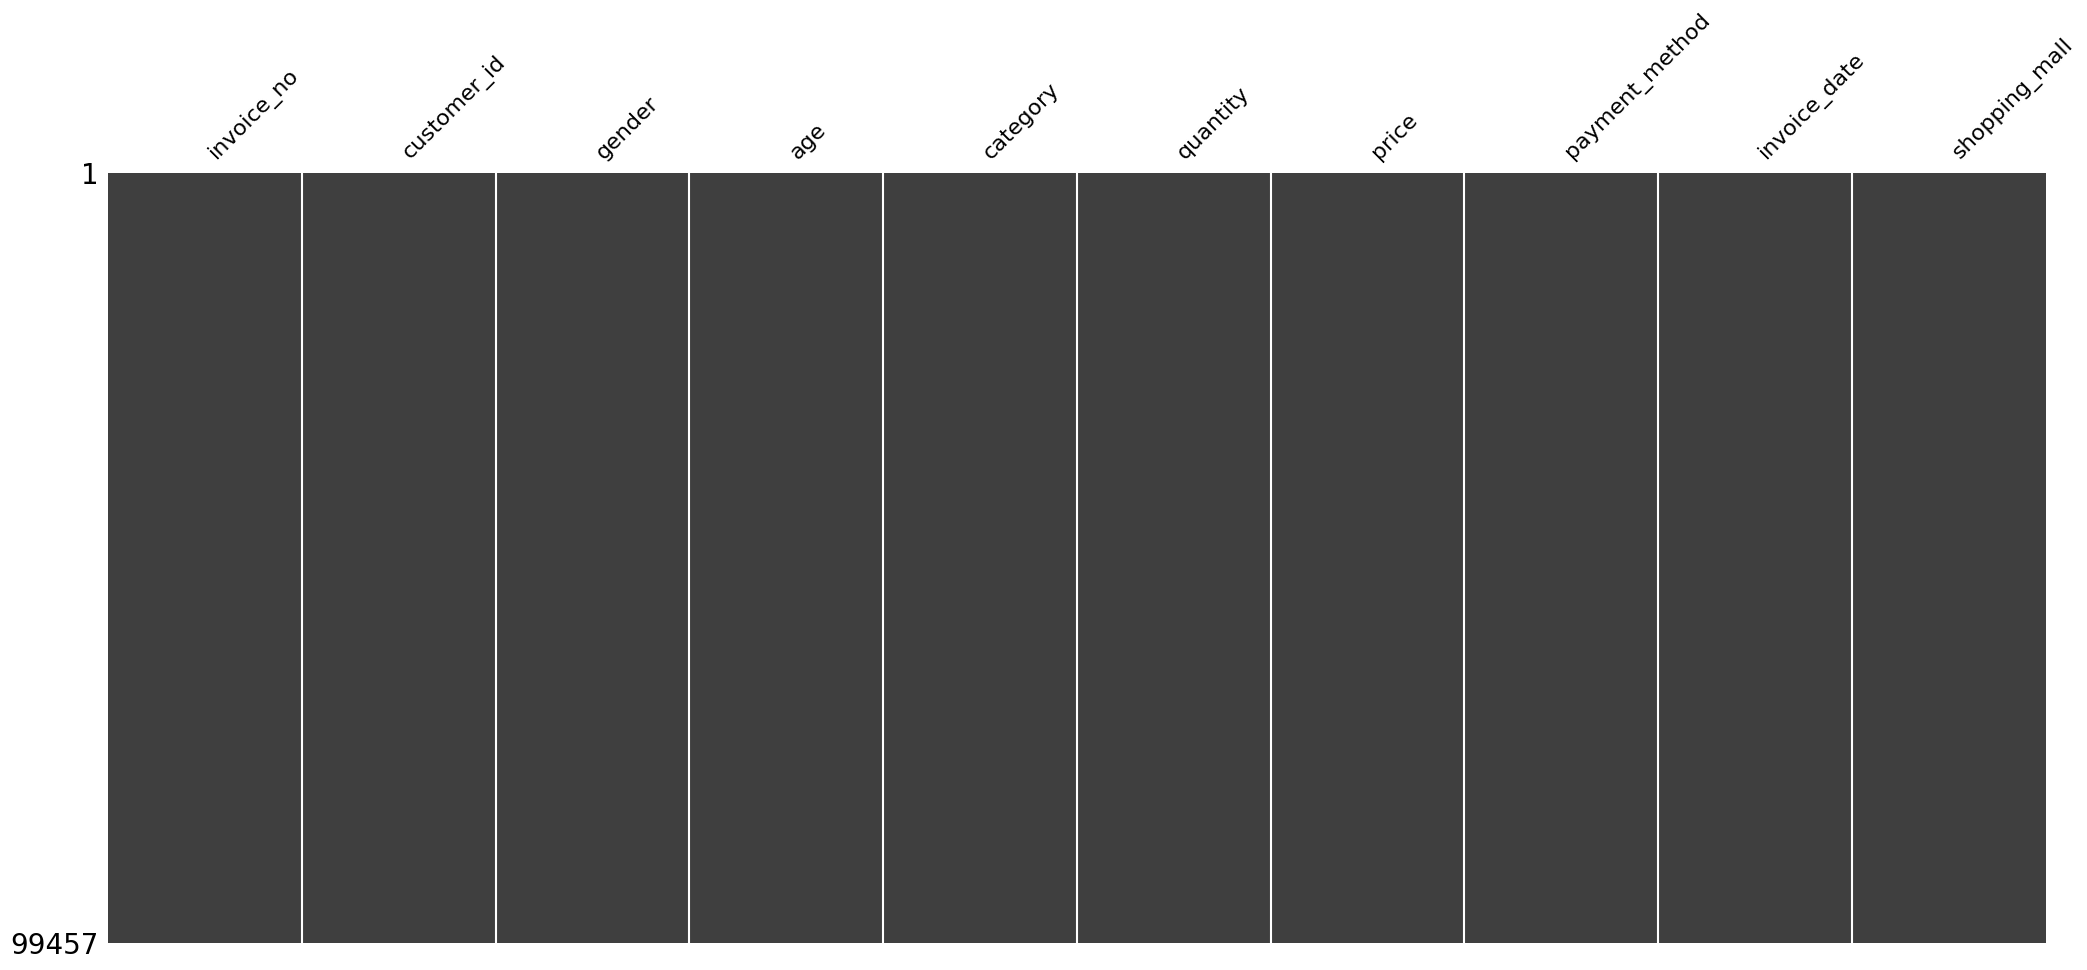

In [ ]:
# Visualisasi pada kolom data apabila terjadi Missing Value
msno.matrix(data_ritel, sparkline=False)

Dalam hasil visualisasi dengan Missing Values bahwa tiap data kolom tidak memiliki data yang kosong atau nilai yang hilang.

In [ ]:
category = data_ritel['category'].value_counts()
print(category)

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64


In [ ]:
gender = data_ritel['gender'].value_counts()
print(gender)

gender
Female    59482
Male      39975
Name: count, dtype: int64


Dari hasil kolom data jenis kelamin atau gender bahwa Wanita paling tinggi dalam hal berbelanja dibandingkan Pria. Hal ini, memang sifat konsumtif Wanita lebih tinggi daripada Pria.

In [ ]:
payment_counts = data_ritel['payment_method'].value_counts()
print(payment_counts)

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64


Jumlah pengguna metode pembayaran saat belanja di pusat perbelanjaan Turki cenderung memilih Cash dengan total transaksi **44447**.

In [ ]:
# Shopping Mall Insights berdasarkan jumlah transaksional
mall = data_ritel['shopping_mall'].value_counts()
print(mall)

shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64


<p>Dari hasil insight analisis yang didapatkan berdasarkan jumlah transaksional di pusat perbelanjaan atau Mall di Turki yaitu,</p>

1. Mall of Istanbul: 19,943 transactions
2. Kanyon: 19,823 transactions
3. Metrocity: 15,011 transactions
4. Metropol AVM: 10,161 transactions
5. Istinye Park: 9,781 transactions
6. Zorlu Center: 5,075 transactions
7. Cevahir AVM: 4,991 transactions
8. Forum Istanbul: 4,947 transactions
9. Viaport Outlet: 4,914 transactions
10. Emaar Square Mall: 4,811 transactions

/tmp/ipython-input-1267619593.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis", ax=ax)


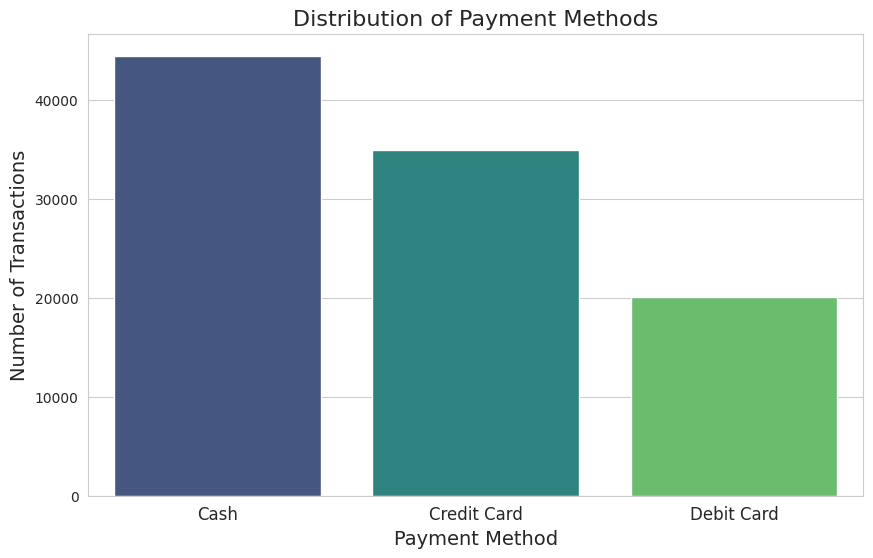

In [ ]:
# Visualize data on payment method and age
# Set the style for the plot
sns.set_style("whitegrid")
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))
# Plotting the bar chart
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis", ax=ax)
# Set plot title and labels
ax.set_title("Distribution of Payment Methods", fontsize=16)
ax.set_xlabel("Payment Method", fontsize=14)
ax.set_ylabel("Number of Transactions", fontsize=14)
# Set x-axis tick labels
ax.set_xticks(payment_counts.index)
ax.set_xticklabels(payment_counts.index.unique(), fontsize=12)
# Display the plot
plt.show()

In [ ]:
# Calculate the average prices for each product category
average_prices = data_ritel.groupby('category')['price'].mean()
average_prices

,price
category,
Books,45.568621
Clothing,901.084021
Cosmetics,122.448626
Food & Beverage,15.671948
Shoes,1807.388568
Souvenir,34.894345
Technology,3156.935548
Toys,107.733185


In [ ]:
# Visualisasi data pada kolom Category dan Harga
# Create a bar chart for the average prices of each product category
fig = px.bar(average_prices,
             x=average_prices.index,
             y=average_prices.values,
             labels={'x': 'Kategori Produk', 'y': 'Rata-rata Harga'},
             title='Rata-rata harga dalam Kategori Produk')

# Show the plot
fig.show()

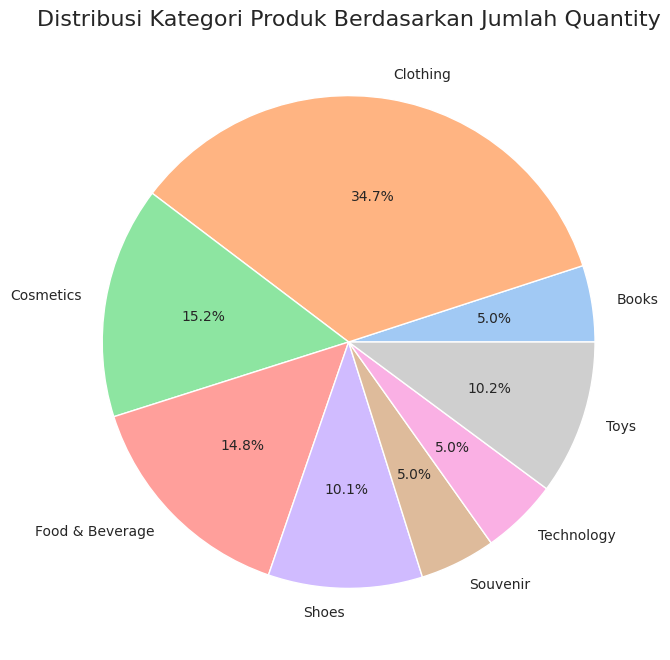

In [ ]:
# Mengelompokkan data berdasarkan kategori dan menjumlahkan quantity
category_quantity = data_ritel.groupby('category')['quantity'].sum()
# Plot pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_quantity, labels=category_quantity.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
# Set judul
plt.title('Distribusi Kategori Produk Berdasarkan Jumlah Quantity', fontsize=16)
# Tampilkan plot
plt.show()

In [ ]:
# Visualisasi total pendapatan disetiap pusat perbelanjaan
total_revenue = data_ritel.groupby('shopping_mall')['price'].sum()
fig = px.bar(total_revenue,
             x = total_revenue.index,
             y = total_revenue.values,
             labels = {'x': 'Shopping Mall', 'y': 'Total Revenue'},
             title = 'Total Pendapatan Setiap Pusat Perbelanjaan')

# Show the plot
fig.show()

In [ ]:
# Top penjualan pada kategori
category_quantity = data_ritel.groupby('category')['quantity'].sum().sort_values(ascending=False)
# Create a bar chart for the top-selling product categories
fig = px.bar(category_quantity,
             x = category_quantity.index,
             y = category_quantity.values,
             labels = {'x': 'Kategori Produk', 'y': 'Total Kuantitas Terjual'},
             title = 'Top Penjualan Kuantitas Kategori')

# Show the plot
fig.show()

<p>Berdasarkan hasil visualiasi diatas menunjukkan bahwa dalam top penjualan berdasarkan kategori yaitu Baju (Clothing), Kosmetik (Cosmetics), F&B (Food and Beverages), Mainan (Toys), dan Sepatu (Shoes) yang paling sering terjual di pusat perbelanjaan maupun di Mall yang ada di negara Turki.</p>

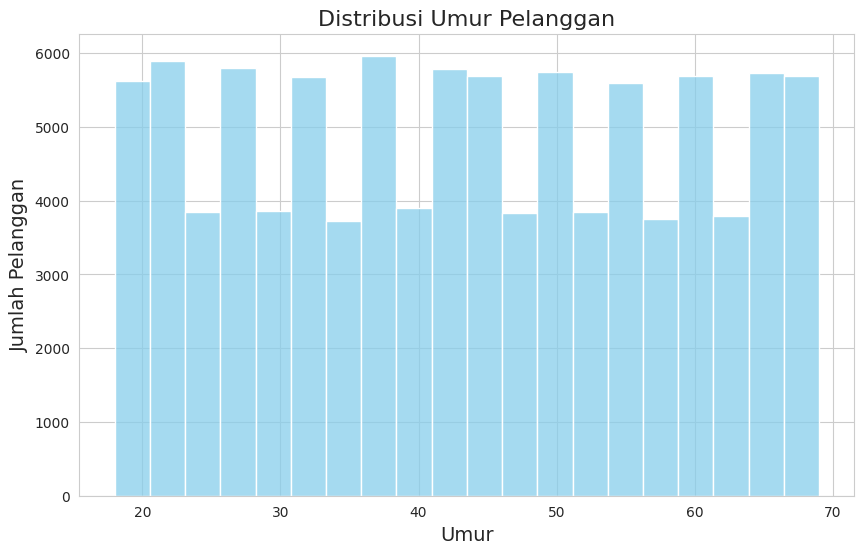

In [ ]:
# Visualisasi data pada kolom umur
# Plot bar chart untuk distribusi umur
plt.figure(figsize=(10, 6))
sns.histplot(data_ritel['age'], bins=20, kde=False, color='skyblue')

# Set judul dan label
plt.title('Distribusi Umur Pelanggan', fontsize=16)
plt.xlabel('Umur', fontsize=14)
plt.ylabel('Jumlah Pelanggan', fontsize=14)

# Tampilkan plot
plt.show()

In [ ]:
# Demografi Pelanggan berdasarkan jenis kelamin dan umur
demographics_summary = data_ritel[['gender', 'age']].describe(include='all')
demographics_summary

,gender,age
count,99457,99457.000000
unique,2,NaN
top,Female,NaN
freq,59482,NaN
mean,NaN,43.427089
std,NaN,14.990054
min,NaN,18.000000
25%,NaN,30.000000
50%,NaN,43.000000
75%,NaN,56.000000


<p>Hasil demografi berdasarkan jenis kelamin dan umur yaitu <b>Perempuan (female)</b> lebih dominan dibandingkan laki-laki dalam hal berbelanja dan rata-rata yang sering belanja di pusat perbelanjaan ataupun Mall yaitu berumur <b>43 tahun</b>.</p>

In [ ]:
# Visualisasi hasil transaksi terbanyak pada pusat perbelanjaan atau mall
fig = px.bar(data_ritel['shopping_mall'].value_counts(),
             x = data_ritel['shopping_mall'].value_counts().index,
             y = data_ritel['shopping_mall'].value_counts().values,
             labels = {'x': 'Shopping Mall', 'y': 'Nominal Transaksi'},
             title = 'Jumlah Nominal Transaksi Pada Pusat Perbelanjaan')
fig.show()

Jumlah transaksional di tiap pusat perbelanjaan yang ada di negara Turki, paling tinggi di Mall of Istanbul dengan nominal transaksi **19.943k Lira Turki**. Hal ini dikarenakan letak pusat perbelanjaan yang strategis di jantung kota Istanbul dan banyaknya warga turis yang datang tidak hanya warga Turki saja dalam hal berbelanja.

### **Data Preprocessing**

In [ ]:
# Encoding data kolom dengan feature mapping
# Encoding pada kolom metode pembayaran
data_ritel['payment_method'] = data_ritel['payment_method'].map({'Cash': 0, 'Credit Card': 1, 'Debit Card': 2})
# Encoding pada kolom jenis kelamin
data_ritel['gender'] = data_ritel['gender'].map({'Female': 0, 'Male': 1})
# Encoding pada kolom pusat perbelanjaan
data_ritel['shopping_mall'] = data_ritel['shopping_mall'].map({'Mall of Istanbul': 0,
                                                               'Kanyon': 1,
                                                               'Metrocity': 2,
                                                               'Metropol AVM': 3,
                                                               'Istinye Park': 4,
                                                               'Zorlu Center': 5,
                                                               'Cevahir AVM': 6,
                                                               'Forum Istanbul': 7,
                                                               'Viaport Outlet': 8,
                                                               'Emaar Square Mall': 9})

In [ ]:
# Encoding data kolom kategori
le = LabelEncoder()
data_ritel['category'] =le.fit_transform(data_ritel['category'])

In [ ]:
data_ritel.sample(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
96613,I229653,C499564,0,64,1,3,900.24,0,15/01/2022,5
50012,I113748,C490033,1,24,7,3,107.52,1,8/10/2022,8
12945,I940495,C348441,0,62,2,1,40.66,0,28/10/2022,1
2443,I115916,C338582,1,18,4,5,3000.85,2,23/08/2022,4
43917,I161433,C259548,0,53,1,1,300.08,0,6/4/2022,1
37969,I323440,C198323,0,30,0,2,30.30,1,16/07/2021,0
18167,I655337,C379314,1,43,3,2,10.46,1,18/10/2021,0
69292,I264249,C426916,0,38,7,1,35.84,2,27/04/2021,3
43321,I176007,C966112,0,47,5,1,11.73,0,14/01/2023,7
53167,I115790,C735859,0,22,1,1,300.08,1,1/3/2023,3


In [ ]:
# Analisa statistik deskriptif
data_ritel.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,99457.0,0.401932,0.490291,0.00,0.00,0.0,1.00,1.0
age,99457.0,43.427089,14.990054,18.00,30.00,43.0,56.00,69.0
category,99457.0,2.762249,2.076012,0.00,1.00,2.0,4.00,7.0
quantity,99457.0,3.003429,1.413025,1.00,2.00,3.0,4.00,5.0
price,99457.0,689.256321,941.184567,5.23,45.45,203.3,1200.32,5250.0
payment_method,99457.0,0.754990,0.767306,0.00,0.00,1.0,1.00,2.0
shopping_mall,99457.0,2.936073,2.697294,0.00,1.00,2.0,4.00,9.0


In [ ]:
# Hapus kolom data yang tidak diperlukan
data_ritel = data_ritel.drop(columns = ['invoice_no', 'customer_id', 'invoice_date'])
data_ritel.sample(10)

,gender,age,category,quantity,price,payment_method,shopping_mall
40538,0,68,2,4,162.64,0,0
71914,0,49,1,5,1500.40,0,1
7832,1,29,7,2,71.68,2,3
48096,1,62,2,2,81.32,0,0
46952,0,52,1,3,900.24,0,1
28513,1,33,2,3,121.98,1,9
94335,0,22,3,2,10.46,0,4
56696,0,32,5,3,35.19,2,5
61163,1,22,1,1,300.08,0,6
26867,0,40,4,5,3000.85,2,1


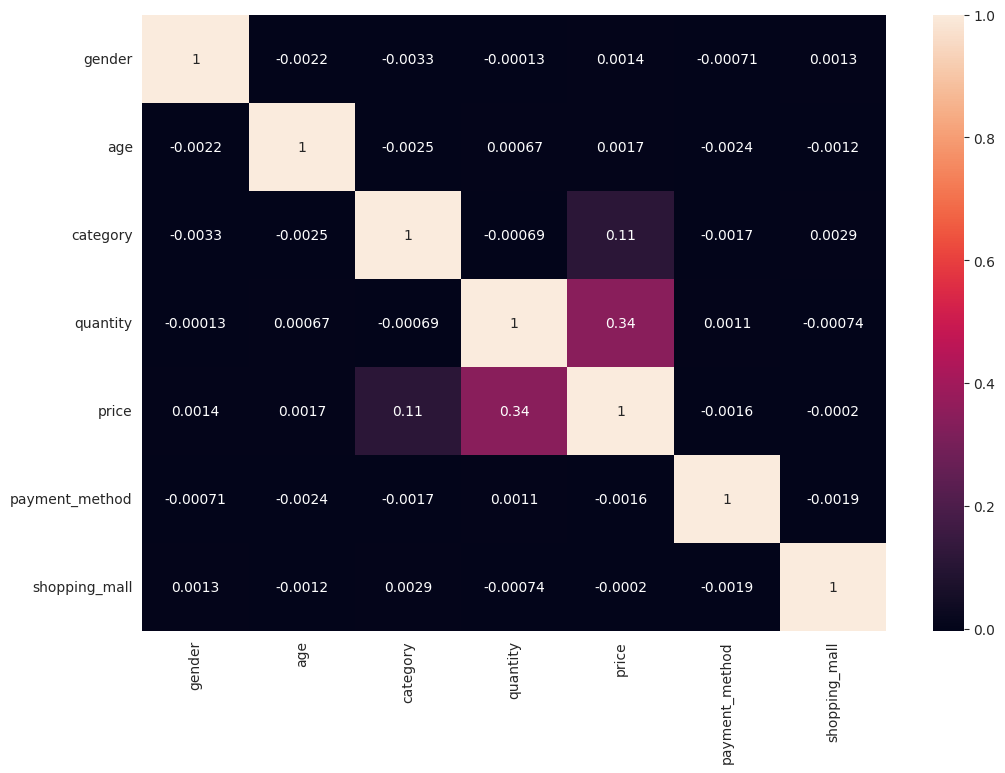

In [ ]:
# Korelasi antara kolom data
plt.figure(figsize = (12, 8))
sns.heatmap(data_ritel.corr(), annot = True)
plt.show()

Hasil analisa korelasi antar kolom data menunjukkan bahwa terdapat korelasi secara negatif, postitif, maupun tidak adanya korelasi.

1. Gender (-0.0033)
2. Age (-0.0025)
3. Quantity (-0.00069)
4. price (0.11)
5. payment_method (-0.0017)
6. shopping_mall (0.0029)

Korelasi yang paling kuat ditunjukkan dalam fitur kolom Price, Gender, Age, Payment_method dan Shopping_mall. Sehingga 5 data kolom ini layak dijadikan kolom fitur.

In [ ]:
# Pemilihan data fitur dan label
features = ['age', 'gender', 'price', 'payment_method', 'shopping_mall']

X = data_ritel[features].values
y = data_ritel['category'].values

### **Splitting Data**

In [ ]:
# Pisahkan data Train dengan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 44)

print('Data training : ', X_train.shape, y_train.shape)
print('Data Testing : ', X_test.shape, y_test.shape)

Data training :  (79565, 5) (79565,)
Data Testing :  (19892, 5) (19892,)


In [ ]:
data_ritel.category.value_counts()

,count
category,
1,34487
2,15097
3,14776
7,10087
4,10034
5,4999
6,4996
0,4981


In [ ]:
# Filling Missing Data
imputer = SimpleImputer(strategy = 'mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [ ]:
# Data Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
# Outlier detection using Z-Score
z_scores = np.abs(zscore(X_train_scaled))
threshold = 5
outliers = np.where(z_scores > threshold)

X_train_no_outliers = X_train_scaled[(z_scores < threshold).all(axis=1)]
y_train_no_outliers = y_train[(z_scores < threshold).all(axis=1)]

## **Modelling**

Dalam tahapan pemodelan ini menggunakan 2 algoritma berbasis tree yaitu **Decision Tree dan Random Forest**. Dua algoritma ini sangat cocok untuk memberikan suatu prediksi dan rekomendasi peluang pada data yang akan diolah dan dihasilkan. Untuk itu, saya menggunakan hyperparameter tuning dalam proses pelatihan dua algoritma tersebut.

In [ ]:
# Decision Tree Classifier
model_dt = DecisionTreeClassifier(random_state = 44)
rfe = RFE(model_dt, n_features_to_select=5)

X_train_rfe = rfe.fit_transform(X_train_no_outliers, y_train_no_outliers)
X_test_rfe = rfe.transform(X_test_scaled)

selected_features = np.array(features)[rfe.support_]
print(selected_features)

['age' 'gender' 'price' 'payment_method' 'shopping_mall']


### **Decision Tree**

In [ ]:
# Training with Pipeline
pipeline = Pipeline([
    ('Classifier', DecisionTreeClassifier(random_state = 44)),

])

param_grid = {
    'Classifier__max_depth': list(range(2, 10)),
    'Classifier__max_leaf_nodes': list(range(2, 10))
}

gridsearch = GridSearchCV(pipeline, param_grid, cv=20)
gridsearch.fit(X_train_rfe, y_train_no_outliers)

best_model = gridsearch.best_estimator_
print(gridsearch.best_params_)

{'Classifier__max_depth': 6, 'Classifier__max_leaf_nodes': 9}


## **Evaluation Model Decision Tree**

Pengujian evaluasi model menggunakan akurasi, presisi, recall dan F1 Score dalam hal kasus model Klasifikasi yang digunakan.

In [ ]:
# Predict the model
y_pred = best_model.predict(X_test_rfe)
print("Accuracy:", accuracy_score(y_test, y_pred))

scores = cross_val_score(best_model, X_train_no_outliers, y_train_no_outliers, cv=20, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)

Accuracy: 0.7967524633018299
Cross-Validation Accuracy Scores: [0.79668258 0.80397085 0.79291279 0.80422217 0.79643126 0.79713424
 0.80065359 0.78783308 0.79788839 0.79738562 0.79361488 0.7933635
 0.79989945 0.79260935 0.79487179 0.7991453  0.80417295 0.79713424
 0.79361488 0.81045752]


In [ ]:
# Classification Report
target_names = ['Books',
                'Clothing',
                'Cosmetics',
                'Food & Beverage',
                'Shoes',
                'Souvenir',
                'Technology',
                'Toys']

print('Classification Report in Hyperparameter Tuning Decision Tree:')
print(classification_report(y_test, y_pred, target_names = le.classes_))

Classification Report in Hyperparameter Tuning Decision Tree:
                 precision    recall  f1-score   support

          Books       0.50      0.42      0.46      1006
       Clothing       0.88      1.00      0.93      6975
      Cosmetics       0.67      1.00      0.80      2962
Food & Beverage       0.83      1.00      0.91      2893
          Shoes       0.85      0.60      0.70      2021
       Souvenir       1.00      0.38      0.56       967
     Technology       1.00      0.61      0.76      1009
           Toys       0.49      0.19      0.27      2059

       accuracy                           0.80     19892
      macro avg       0.78      0.65      0.67     19892
   weighted avg       0.79      0.80      0.77     19892



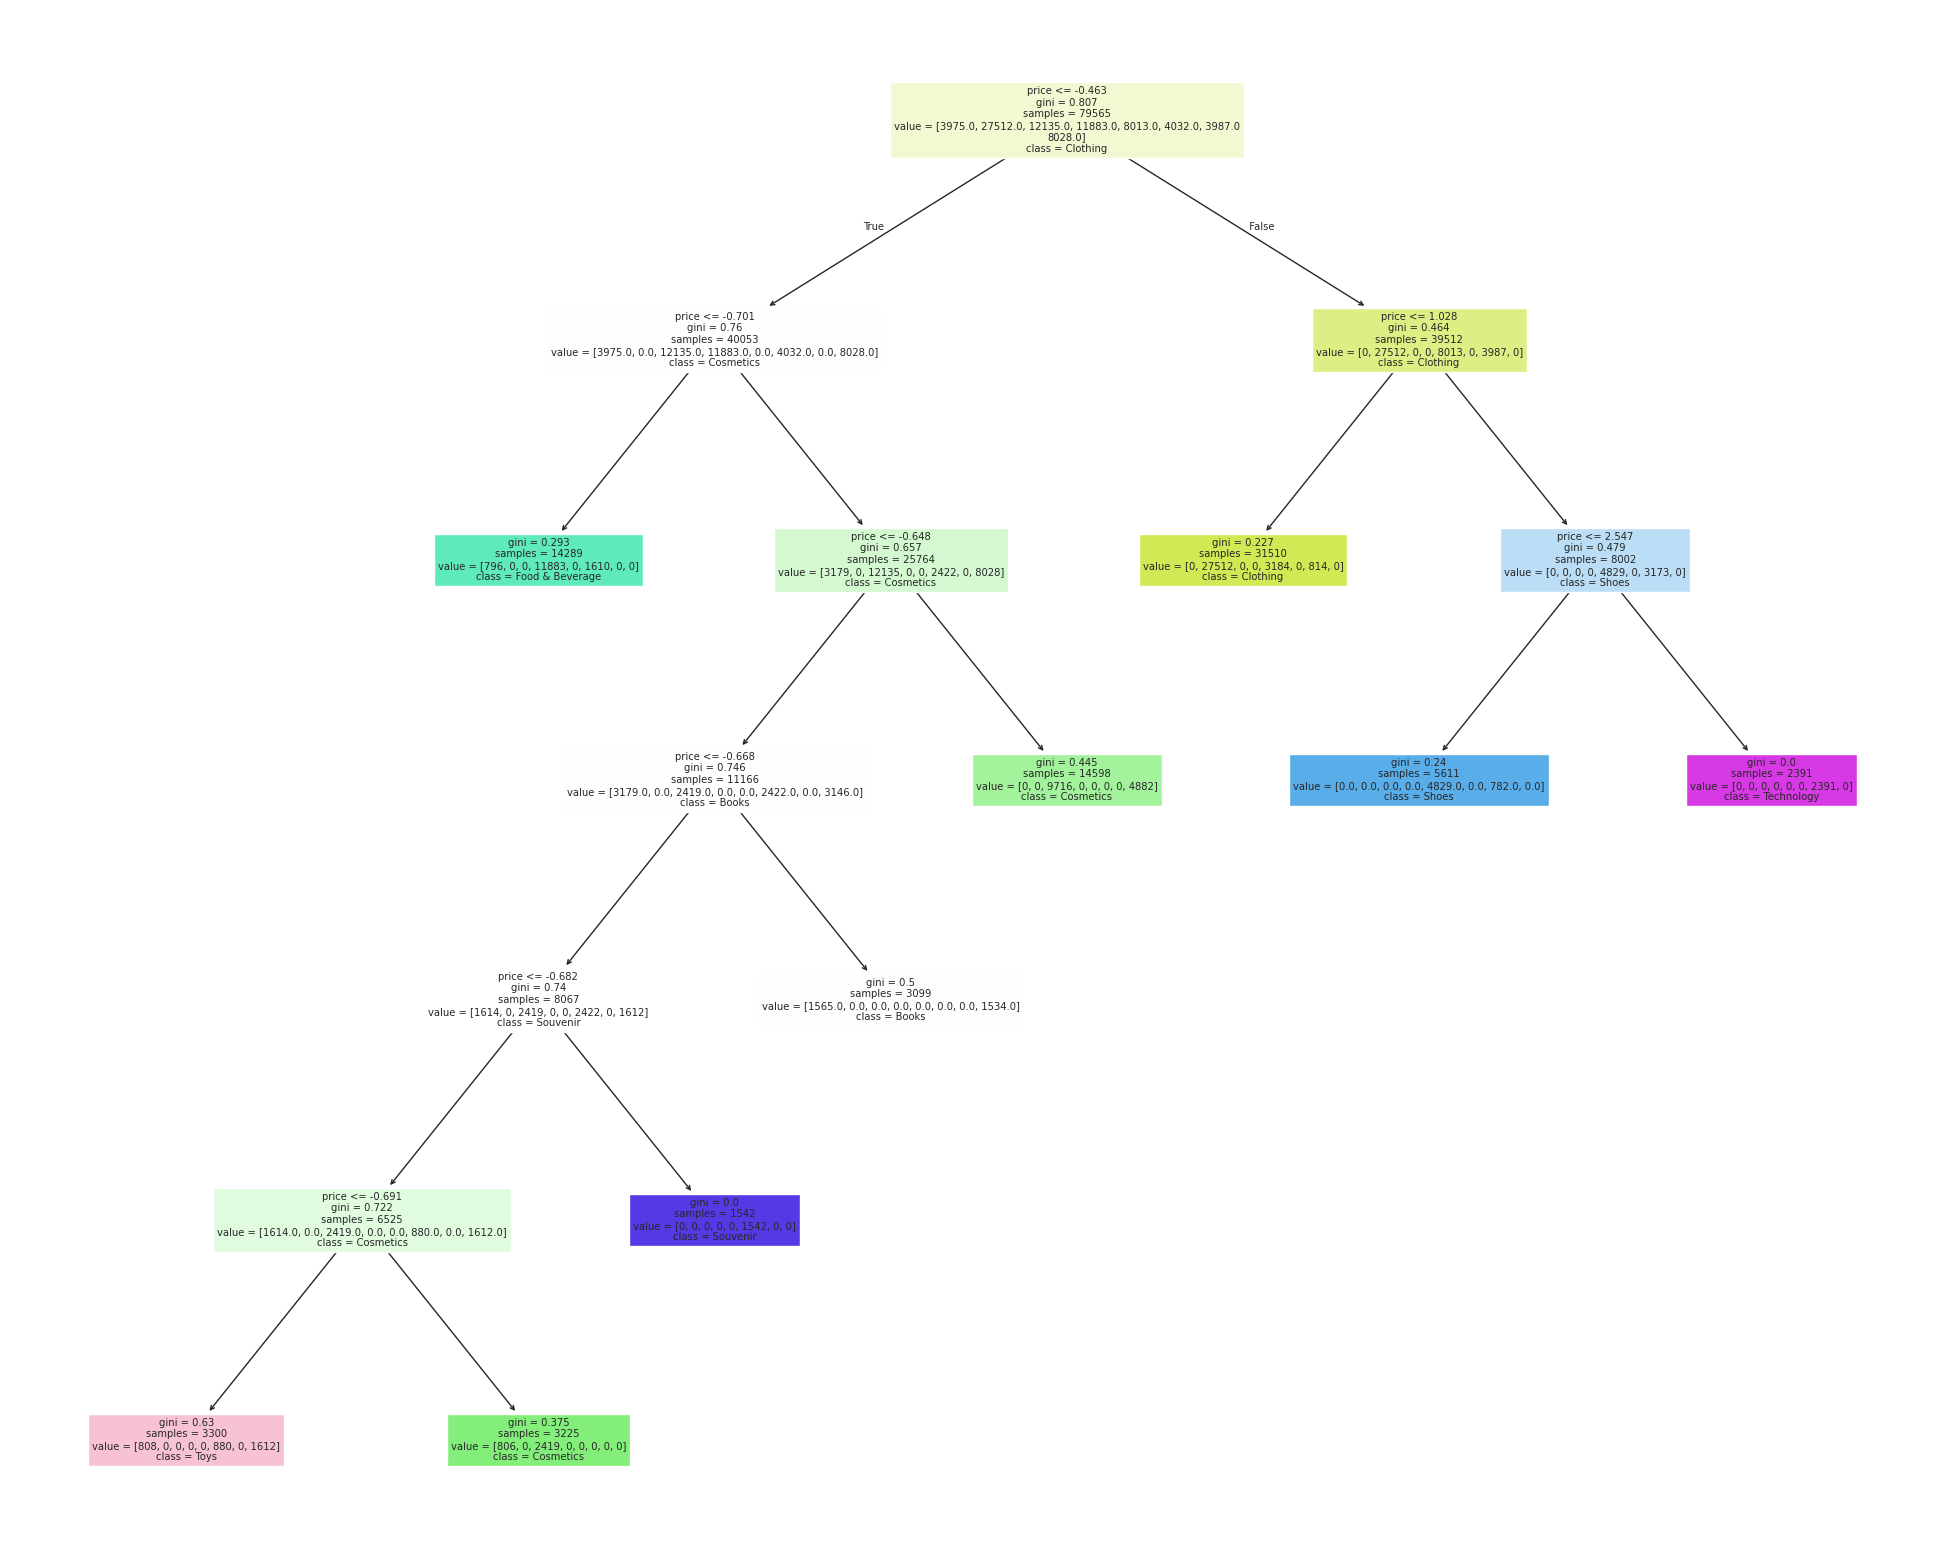

In [ ]:
# Plot Decision Tree
# Assuming 'best_model' is your Pipeline object
decision_tree = best_model.named_steps['Classifier']  # Replace 'Classifier' with your step name
plt.figure(figsize = (25, 20))
tree.plot_tree(decision_tree,
               feature_names = features,
               class_names = target_names,
               filled=True)

plt.show()

### **Random Forest**

In [ ]:
# Random Forest
model_rf = RandomForestClassifier(random_state = 44)
rfe = RFE(model_rf, n_features_to_select = 5)

X_train_rfe = rfe.fit_transform(X_train_no_outliers, y_train_no_outliers)
X_test_rfe = rfe.transform(X_test_scaled)

selected_features = np.array(features)[rfe.support_]
print(selected_features)

['age' 'gender' 'price' 'payment_method' 'shopping_mall']


In [ ]:
# Training with Pipeline
pipeline = Pipeline([
    ('Classifier', RandomForestClassifier(random_state = 44)),
])

param_grid = {
    'Classifier__n_estimators': [100, 200, 300],
    'Classifier__max_depth': [None, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, cv = 5)
grid_search.fit(X_train_rfe, y_train_no_outliers)

best_model_rf = grid_search.best_estimator_
print(grid_search.best_params_)

{'Classifier__max_depth': None, 'Classifier__n_estimators': 300}


## **Evaluation Model Random Forest**

In [ ]:
y_pred_rf = best_model_rf.predict(X_test_rfe)

print("Accuracy Score :", accuracy_score(y_test, y_pred_rf))

Accuracy Score : 0.9987432133521014


In [ ]:
scores = cross_val_score(best_model_rf, X_train_no_outliers, y_train_no_outliers, cv = 5, scoring = 'accuracy')

print("Cross-Validation Accuracy Scores: ", scores)

Cross-Validation Accuracy Scores:  [0.99754917 0.99729781 0.99729781 0.99780054 0.99742349]


In [ ]:
print('Classification Report in Hyperparameter Tuning Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names = target_names))

Classification Report in Hyperparameter Tuning Random Forest:
                 precision    recall  f1-score   support

          Books       1.00      1.00      1.00      1006
       Clothing       1.00      1.00      1.00      6975
      Cosmetics       1.00      1.00      1.00      2962
Food & Beverage       1.00      1.00      1.00      2893
          Shoes       1.00      1.00      1.00      2021
       Souvenir       1.00      1.00      1.00       967
     Technology       1.00      0.99      1.00      1009
           Toys       1.00      0.99      1.00      2059

       accuracy                           1.00     19892
      macro avg       1.00      1.00      1.00     19892
   weighted avg       1.00      1.00      1.00     19892



Hasil akurasi dengan hyperparameter tuning Random Forest sangat bagus mencapai 100%. Dan jika dilihat dari segi rata-rata bobot pelatihannya sama seperti macro average yaitu mencapai 100%. Walaupun dari segi recall terlihat beberapa hasil kelas yang kurang namun jika dilihat dalam hal evaluasi lebih mengutamakan Weighted Average.

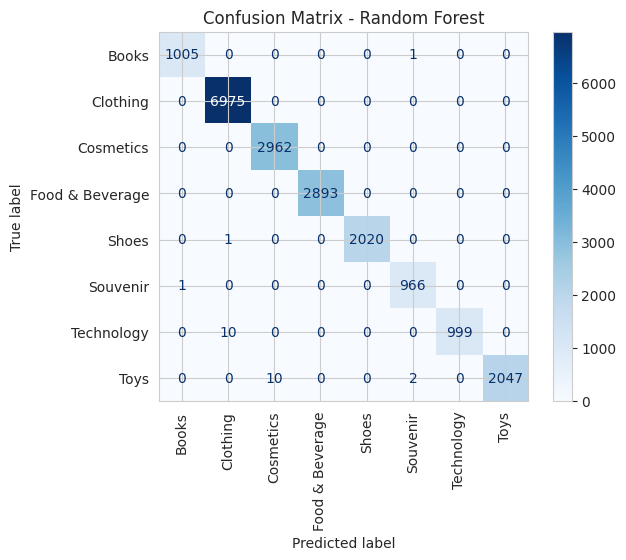

In [ ]:
# prompt: create a confusion matrix plot in Random forest
# Assuming 'y_test' and 'y_pred_rf' are your true and predicted labels respectively
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_names)
disp.plot(cmap = 'Blues', xticks_rotation = 'vertical')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:
# Assuming 'best_model_rf' is your best performing model (Random Forest in this case)

# Input features for new data (replace with actual values)
new_data = np.array([[30, 0, 50, 1, 0]])  # Example: age, gender, price, payment_method, shopping_mall

# Preprocess the new data (scaling)
new_data_scaled = scaler.transform(new_data)

# Feature selection using RFE (if used during training)
new_data_rfe = rfe.transform(new_data_scaled)

# Make prediction
predicted_category = best_model.predict(new_data_rfe)

# Decode the predicted category (if label encoding was used)
predicted_category_name = le.inverse_transform(predicted_category)

print("Predicted Category (Numerical):", predicted_category)
print("Predicted Category (Name):", predicted_category_name)


Predicted Category (Numerical): [5]
Predicted Category (Name): ['Souvenir']


In [ ]:
# Testing model
umur = 49 #@param {type:"slider", min:10, max:100, step:1}
jenis_kelamin = 1 #@param [0, 1] {type:"raw"}
harga = 5000 #@param {type: "number"}
metode_pembayaran = 0 #@param [0, 1, 2] {type:"raw"}
perbelanjaan = 0 #@param [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] {type : "raw"}

umur = umur/100

data_baru = [umur, jenis_kelamin, harga, metode_pembayaran, perbelanjaan]
data_baru = np.array(data_baru)
data_baru = data_baru.reshape(1, -1)

data_baru_scaled = scaler.transform(data_baru)
data_baru_rfe = rfe.transform(data_baru_scaled)

prediction_model = best_model_rf.predict(data_baru_rfe)
prediction_name = le.inverse_transform(prediction_model)

print('Kategori Produk yang Dibeli (Numerik):', prediction_model)
print('Kategori Produk yang Dibeli:', prediction_name)

Kategori Produk yang Dibeli (Numerik): [6]
Kategori Produk yang Dibeli: ['Technology']


**Kesimpulan:**

| Algoritma | Akurasi  |
|:---:|:---:|
| Decision Tree | 80% |
| Random Forest | 99% |

Hasil analisa yang didapatkan dalam pelatihan model berbasis algoritma tree ini bahwa algoritma Random Forest mendapatkan hasil terbaik dari segi evaluasi metriks yang ditetapkan dengan skor akurasi sebesar **99%** dibandingkan algoritma Decision Tree hanya **80%** saja. Selain itu, dalam evaluasi metriks yang saya gunakan bahwa Random Forest sudah sangat baik untuk nilai probabilitas dan confusion matrix yang ditetapkan walaupun ada beberapa yang masih kurang terdeteksi dengan baik.

Selain itu, dalam perbandingan model yang ditetapkan. Saya melakukan evaluasi terbaik untuk prediksi berbasis peluang ini dengan menggunakan data baru.

## **Save The Model**

In [ ]:
# Save model using Pickle
with open('/content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.pkl', 'wb') as file:
  pickle.dump(best_model_rf, file)

In [ ]:
# Load Model
filename = '/content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.pkl'

model = pickle.load(open(filename, 'rb'))
model.score(X_test_rfe, y_test)

0.9987432133521014

In [ ]:
import joblib

# Save model using joblib
joblib_filename = '/content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.joblib'
joblib.dump(best_model_rf, joblib_filename)

print(f"Model saved to {joblib_filename}")

Model saved to /content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.joblib


In [ ]:
# Define the input features for the ONNX model
# Assuming `X_train_rfe` (scaled and RFE-transformed data) was used for training
# We need the shape of a single input sample (5 features)
initial_type = [('float_input', FloatTensorType([None, X_train_rfe.shape[1]]))]

# Convert the scikit-learn Random Forest model to ONNX format
onnx_model = convert_sklearn(best_model_rf, initial_types=initial_type)

# Define the path to save the ONNX model
onnx_filename = '/content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.onnx'

# Save the ONNX model to a file
with open(onnx_filename, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Model saved to {onnx_filename} in ONNX format.")

# Optional: Verify the ONNX model
onnx_model_loaded = onnx.load(onnx_filename)
onnx.checker.check_model(onnx_model_loaded)
print("ONNX model check successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.7 MB/s eta 0:00:00
Model saved to /content/drive/MyDrive/Proyek/Data Science/Retail System/best_model_rf.onnx in ONNX format.
ONNX model check successful!


In [ ]:
# Testing model
umur = 38 #@param {type:"slider", min:10, max:100, step:1}
jenis_kelamin = 1 #@param [0, 1] {type:"raw"}
harga = 2000 #@param {type: "number"}
metode_pembayaran = 1 #@param [0, 1, 2] {type:"raw"}
perbelanjaan = 5 #@param [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] {type : "raw"}

umur = umur/100

data_baru = [umur, jenis_kelamin, harga, metode_pembayaran, perbelanjaan]
data_baru = np.array(data_baru)
data_baru = data_baru.reshape(1, -1)

data_baru_scaled = scaler.transform(data_baru)
data_baru_rfe = rfe.transform(data_baru_scaled)

prediction_model = model.predict(data_baru_rfe)
prediction_name = le.inverse_transform(prediction_model)

print('Kategori Produk yang Dibeli (Numerik):', prediction_model)
print('Kategori Produk yang Dibeli:', prediction_name)

Kategori Produk yang Dibeli (Numerik): [6]
Kategori Produk yang Dibeli: ['Technology']
